# Prueba Técnica: Sistema Híbrido de Recomendación y Personalización de Retail (Gen AI + ML)

**Objetivo:** construir un prototipo reproducible que combina:

1. Extracción tipo RFM con SQL.
2. Generación de datos sintéticos para al menos 1,000 clientes.
3. Segmentación/modelado predictivo con Machine Learning tradicional.
4. Generación de mensajes personalizados con GenAI usando salida estructurada JSON.

> Nota: este notebook no requiere datos reales ni API keys para ejecutarse. La integración con LLM incluye un modo `mock=True` por defecto.

## Tarea 1: Extracción y Procesamniento de Datos (SQL y Python)

## 1.1. Consulta SQL

La consulta asume tres tablas relacionales:

- `clientes(cliente_id, nombre, email, fecha_registro)`
- `transacciones(transaccion_id, cliente_id, producto_id, fecha_transaccion, cantidad, monto_total)`
- `productos(producto_id, nombre_producto, categoria)`

Extrae por cliente: ID, recencia, frecuencia, monto total y categoría más comprada.

In [1]:
SQL_QUERY = """
WITH rfm AS (
    SELECT
        c.cliente_id,
        DATE_PART('day', CURRENT_DATE - MAX(t.fecha_transaccion)) AS recencia_dias,
        COUNT(DISTINCT t.transaccion_id) AS frecuencia,
        COALESCE(SUM(t.monto_total), 0) AS monto_total_gastado
    FROM clientes c
    LEFT JOIN transacciones t
        ON c.cliente_id = t.cliente_id
    GROUP BY c.cliente_id
), categoria_rank AS (
    SELECT
        t.cliente_id,
        p.categoria,
        COUNT(*) AS compras_categoria,
        ROW_NUMBER() OVER (
            PARTITION BY t.cliente_id
            ORDER BY COUNT(*) DESC, p.categoria ASC
        ) AS rn
    FROM transacciones t
    INNER JOIN productos p
        ON t.producto_id = p.producto_id
    GROUP BY t.cliente_id, p.categoria
)
SELECT
    r.cliente_id,
    r.recencia_dias,
    r.frecuencia,
    r.monto_total_gastado,
    COALESCE(cr.categoria, 'Sin compras') AS categoria_mas_comprada
FROM rfm r
LEFT JOIN categoria_rank cr
    ON r.cliente_id = cr.cliente_id
   AND cr.rn = 1
ORDER BY r.cliente_id;
"""
print(SQL_QUERY)


WITH rfm AS (
    SELECT
        c.cliente_id,
        DATE_PART('day', CURRENT_DATE - MAX(t.fecha_transaccion)) AS recencia_dias,
        COUNT(DISTINCT t.transaccion_id) AS frecuencia,
        COALESCE(SUM(t.monto_total), 0) AS monto_total_gastado
    FROM clientes c
    LEFT JOIN transacciones t
        ON c.cliente_id = t.cliente_id
    GROUP BY c.cliente_id
), categoria_rank AS (
    SELECT
        t.cliente_id,
        p.categoria,
        COUNT(*) AS compras_categoria,
        ROW_NUMBER() OVER (
            PARTITION BY t.cliente_id
            ORDER BY COUNT(*) DESC, p.categoria ASC
        ) AS rn
    FROM transacciones t
    INNER JOIN productos p
        ON t.producto_id = p.producto_id
    GROUP BY t.cliente_id, p.categoria
)
SELECT
    r.cliente_id,
    r.recencia_dias,
    r.frecuencia,
    r.monto_total_gastado,
    COALESCE(cr.categoria, 'Sin compras') AS categoria_mas_comprada
FROM rfm r
LEFT JOIN categoria_rank cr
    ON r.cliente_id = cr.cliente_id
   AND cr.rn = 1

## 1.2. Generación de Dataset Sintético 

### 1.2.1 Setup del entorno

In [2]:
import os
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    accuracy_score
)

warnings.filterwarnings('ignore')
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

### 1.2.2. Dataset sintético

Se simulan 1,500 clientes con variables RFM y categoría favorita. La variable objetivo se define con reglas de negocio para representar tres segmentos:

- `Alto Valor`: clientes con alto gasto y frecuencia alta.
- `En Riesgo`: clientes con alta recencia, baja frecuencia o bajo gasto.
- `Estandar`: clientes intermedios.

In [3]:
def generate_synthetic_retail_dataset(n_customers: int = 1500, random_state: int = 42) -> pd.DataFrame:
    rng = np.random.default_rng(random_state)
    categories = np.array([
        'Construccion', 'Herramientas', 'Pintura', 'Electricidad',
        'Plomeria', 'Jardin', 'Ferreteria', 'Hogar'
    ])

    # Variables base con distribuciones realistas y sesgadas hacia clientes pequeños/medianos
    recency = rng.gamma(shape=2.2, scale=28, size=n_customers).astype(int)
    recency = np.clip(recency, 1, 365)

    frequency = rng.negative_binomial(n=5, p=0.36, size=n_customers) + 1
    frequency = np.clip(frequency, 1, 80)

    avg_ticket = rng.lognormal(mean=3.75, sigma=0.65, size=n_customers)
    monetary = frequency * avg_ticket * rng.normal(1.0, 0.12, size=n_customers)
    monetary = np.clip(monetary, 10, None).round(2)

    favorite_category = rng.choice(
        categories,
        size=n_customers,
        p=[0.18, 0.18, 0.12, 0.13, 0.12, 0.09, 0.12, 0.06]
    )

    df = pd.DataFrame({
        'cliente_id': [f'C{str(i).zfill(5)}' for i in range(1, n_customers + 1)],
        'recencia_dias': recency,
        'frecuencia': frequency,
        'monto_total_gastado': monetary,
        'categoria_mas_comprada': favorite_category
    })

    # Reglas de negocio para simular segmento/target
    q_monetary_70 = df['monto_total_gastado'].quantile(0.70)
    q_frequency_65 = df['frecuencia'].quantile(0.65)
    q_monetary_30 = df['monto_total_gastado'].quantile(0.30)

    conditions = [
        (df['monto_total_gastado'] >= q_monetary_70) & (df['frecuencia'] >= q_frequency_65) & (df['recencia_dias'] <= 90),
        (df['recencia_dias'] >= 120) | ((df['frecuencia'] <= 3) & (df['monto_total_gastado'] <= q_monetary_30))
    ]
    choices = ['Alto Valor', 'En Riesgo']
    df['segmento_cliente'] = np.select(conditions, choices, default='Estandar')

    return df

clientes_df = generate_synthetic_retail_dataset()
clientes_df.head()

,cliente_id,recencia_dias,frecuencia,monto_total_gastado,categoria_mas_comprada,segmento_cliente
0,C00001,64,6,192.57,Plomeria,Estandar
1,C00002,86,9,285.31,Ferreteria,Estandar
2,C00003,57,7,232.42,Ferreteria,Estandar
3,C00004,51,10,757.73,Electricidad,Estandar
4,C00005,93,6,354.22,Construccion,Estandar


### 1.2.3. Exploración de los datos generados

In [6]:
print(clientes_df.shape)
display(clientes_df.describe(include='all'))
print('Distribución de segmentos:')
print(clientes_df['segmento_cliente'].value_counts(normalize=True).round(3))

(1500, 6)


,cliente_id,recencia_dias,frecuencia,monto_total_gastado,categoria_mas_comprada,segmento_cliente
count,1500,1500.000000,1500.000000,1500.000000,1500,1500
unique,1500,NaN,NaN,NaN,8,3
top,C00001,NaN,NaN,NaN,Herramientas,Estandar
freq,1,NaN,NaN,NaN,273,1045
mean,NaN,61.831333,9.808667,521.053813,NaN,NaN
std,NaN,42.612801,4.885622,488.027205,NaN,NaN
min,NaN,1.000000,1.000000,11.100000,NaN,NaN
25%,NaN,31.000000,6.000000,206.560000,NaN,NaN
50%,NaN,54.000000,9.000000,375.340000,NaN,NaN
75%,NaN,82.000000,13.000000,664.200000,NaN,NaN


Distribución de segmentos:
segmento_cliente
Estandar      0.697
Alto Valor    0.162
En Riesgo     0.141
Name: proportion, dtype: float64


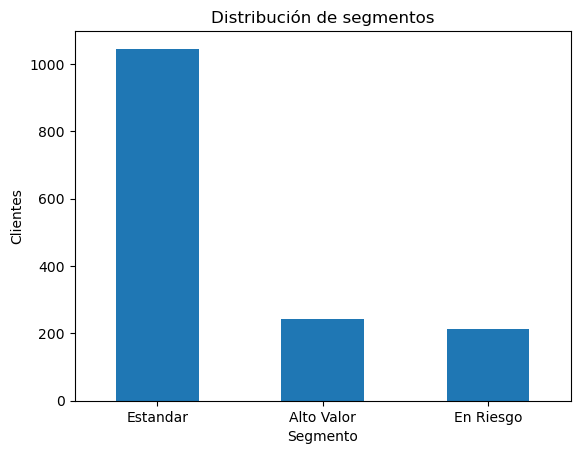

In [7]:
ax = clientes_df['segmento_cliente'].value_counts().plot(kind='bar', title='Distribución de segmentos')
ax.set_xlabel('Segmento')
ax.set_ylabel('Clientes')
plt.xticks(rotation=0)
plt.show()

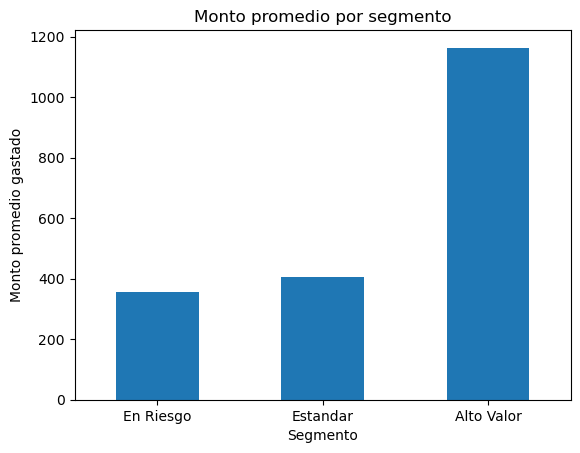

In [8]:
ax = clientes_df.groupby('segmento_cliente')['monto_total_gastado'].mean().sort_values().plot(
    kind='bar', title='Monto promedio por segmento'
)
ax.set_xlabel('Segmento')
ax.set_ylabel('Monto promedio gastado')
plt.xticks(rotation=0)
plt.show()

## Tarea 2: Modelo Predictivo (Machine Learning)

### 2.1. Entrenamiento de modelo predictivo y evaluación de rendimiento

In [10]:
features = ['recencia_dias', 'frecuencia', 'monto_total_gastado', 'categoria_mas_comprada']
target = 'segmento_cliente'

X = clientes_df[features]
y = clientes_df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y
)

numeric_features = ['recencia_dias', 'frecuencia', 'monto_total_gastado']
categorical_features = ['categoria_mas_comprada']

preprocess = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)

model = RandomForestClassifier(
    n_estimators=300,
    max_depth=8,
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=RANDOM_STATE
)

clf = Pipeline(steps=[
    ('preprocess', preprocess),
    ('model', model)
])

clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

print('Accuracy:', round(accuracy_score(y_test, y_pred), 4))
print('F1 macro:', round(f1_score(y_test, y_pred, average='macro'), 4))
print('Reporte de clasificación:')
print(classification_report(y_test, y_pred))

Accuracy: 0.9893
F1 macro: 0.9855
Reporte de clasificación:
              precision    recall  f1-score   support

  Alto Valor       1.00      0.98      0.99        61
   En Riesgo       0.95      1.00      0.97        53
    Estandar       1.00      0.99      0.99       261

    accuracy                           0.99       375
   macro avg       0.98      0.99      0.99       375
weighted avg       0.99      0.99      0.99       375



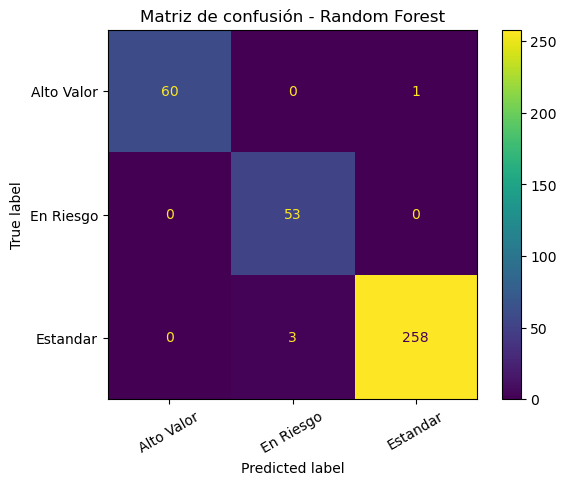

In [11]:
labels = sorted(y.unique())
cm = confusion_matrix(y_test, y_pred, labels=labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(values_format='d')
plt.title('Matriz de confusión - Random Forest')
plt.xticks(rotation=30)
plt.show()

In [12]:
# Validación cruzada estratificada
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
f1_scores = cross_val_score(clf, X, y, cv=cv, scoring='f1_macro')
print('F1 macro CV:', np.round(f1_scores, 4))
print('F1 macro promedio:', round(f1_scores.mean(), 4), '+/-', round(f1_scores.std(), 4))

F1 macro CV: [0.9952 1.     0.9958 1.     0.9864]
F1 macro promedio: 0.9955 +/- 0.005


,feature,importance
2,monto_total_gastado,0.346031
0,recencia_dias,0.344802
1,frecuencia,0.293129
9,categoria_mas_comprada_Pintura,0.002772
6,categoria_mas_comprada_Herramientas,0.002457
8,categoria_mas_comprada_Jardin,0.002431
3,categoria_mas_comprada_Construccion,0.002407
4,categoria_mas_comprada_Electricidad,0.002065
10,categoria_mas_comprada_Plomeria,0.001405
5,categoria_mas_comprada_Ferreteria,0.001386


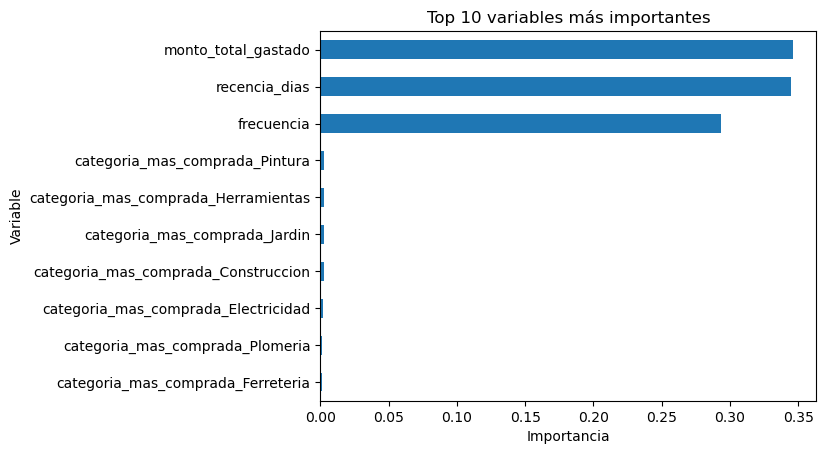

In [13]:
# Importancia de variables
trained_rf = clf.named_steps['model']
ohe = clf.named_steps['preprocess'].named_transformers_['cat']
cat_names = list(ohe.get_feature_names_out(categorical_features))
feature_names = numeric_features + cat_names

importances = pd.DataFrame({
    'feature': feature_names,
    'importance': trained_rf.feature_importances_
}).sort_values('importance', ascending=False)

display(importances.head(10))

ax = importances.head(10).sort_values('importance').plot(
    x='feature', y='importance', kind='barh', legend=False,
    title='Top 10 variables más importantes'
)
ax.set_xlabel('Importancia')
ax.set_ylabel('Variable')
plt.show()

### 2.2. Explicación breve de porque se elijió el algoritmo random forest y no otro
Se utiliza **Random Forest** porque:

- Maneja relaciones no lineales entre recencia, frecuencia y monto.
- Es robusto para datos tabulares.
- Permite revisar importancia de variables.
- No exige supuestos fuertes de normalidad o linealidad.

Aunque K-Means también sería válido para segmentación no supervisada, aquí se simula una variable objetivo y por eso se usa clasificación supervisada.

## Tarea 3: Personalización Generativa (GenAI)

La función siguiente recibe el perfil del cliente y devuelve un JSON con:

- `asunto`
- `cuerpo_mensaje`
- `cupon_descuento_sugerido`

Incluye:

- Rol: especialista senior en marketing retail.
- Few-shot prompting: ejemplos por segmento.
- Structured Outputs: esquema JSON esperado.
- Modo `mock=True` para ejecutar sin API key.

In [20]:
MESSAGE_SCHEMA = {
    'type': 'object',
    'properties': {
        'asunto': {'type': 'string'},
        'cuerpo_mensaje': {'type': 'string'},
        'cupon_descuento_sugerido': {'type': 'string'}
    },
    'required': ['asunto', 'cuerpo_mensaje', 'cupon_descuento_sugerido'],
    'additionalProperties': False
}

FEW_SHOT_EXAMPLES = """
Ejemplo 1:
Cliente: segmento=Alto Valor, categoria=Herramientas, monto=1450
Salida JSON:
{
  "asunto": "Gracias por construir con nosotros",
  "cuerpo_mensaje": "Como uno de nuestros clientes más valiosos, queremos premiar tu preferencia en herramientas con una oferta especial para tu próximo proyecto.",
  "cupon_descuento_sugerido": "VIP15"
}

Ejemplo 2:
Cliente: segmento=En Riesgo, categoria=Pintura, monto=120
Salida JSON:
{
  "asunto": "Te extrañamos en Cochez",
  "cuerpo_mensaje": "Hace un tiempo no compras con nosotros. Tenemos novedades en pintura que pueden ayudarte a renovar tus espacios con mejor precio.",
  "cupon_descuento_sugerido": "VUELVE20"
}

Ejemplo 3:
Cliente: segmento=Estandar, categoria=Plomeria, monto=390
Salida JSON:
{
  "asunto": "Una oferta para tu próximo proyecto",
  "cuerpo_mensaje": "Gracias por elegirnos. Preparamos una recomendación en plomería para que sigas avanzando en tus reparaciones y mejoras del hogar.",
  "cupon_descuento_sugerido": "PROYECTO10"
}
"""


def mock_llm_response(segmento: str, categoria: str, monto: float) -> dict:
    if segmento == 'Alto Valor':
        return {
            'asunto': f'Beneficio exclusivo en {categoria}',
            'cuerpo_mensaje': (
                f'Gracias por tu preferencia y por confiar en Cochez. '
                f'Por tus compras acumuladas de B/. {monto:,.2f}, queremos ofrecerte '
                f'una recompensa especial en productos de {categoria} para tu próximo proyecto.'
            ),
            'cupon_descuento_sugerido': 'VIP15'
        }
    if segmento == 'En Riesgo':
        return {
            'asunto': 'Te extrañamos en Cochez',
            'cuerpo_mensaje': (
                f'Queremos volver a ayudarte con tus proyectos. Tenemos nuevas opciones en {categoria} '
                f'y preparamos un descuento especial para que regreses con una mejor oferta.'
            ),
            'cupon_descuento_sugerido': 'VUELVE20'
        }
    return {
        'asunto': f'Ideas para tu próximo proyecto en {categoria}',
        'cuerpo_mensaje': (
            f'Gracias por comprar en Cochez. Según tu interés en {categoria}, '
            f'tenemos recomendaciones y una promoción especial para seguir acompañando tus proyectos.'
        ),
        'cupon_descuento_sugerido': 'PROYECTO10'
    }


def generate_personalized_message(segmento: str, categoria: str, monto: float, mock: bool = True) -> dict:
    """Genera mensaje personalizado. Por defecto usa mock para evitar consumo de créditos."""
    if mock:
        return mock_llm_response(segmento, categoria, monto)

    # Requiere: pip install openai
    # Exportar OPENAI_API_KEY antes de ejecutar.
    from openai import OpenAI
    client = OpenAI(api_key=os.environ.get('OPENAI_API_KEY'))

    prompt = f"""
Eres un especialista senior en CRM y marketing personalizado para retail ferretero.
Tu tarea es generar un mensaje breve, persuasivo y respetuoso para un cliente de Cochez.
No inventes datos personales. No uses promesas engañosas. Mantén tono profesional y cercano.

{FEW_SHOT_EXAMPLES}

Cliente actual:
- Segmento ML: {segmento}
- Última/categoría más comprada: {categoria}
- Monto total gastado: B/. {monto:,.2f}

Devuelve únicamente un JSON válido con las claves solicitadas.
"""

    response = client.responses.create(
        model='gpt-4.1-mini',
        input=prompt,
        text={
            'format': {
                'type': 'json_schema',
                'name': 'mensaje_fidelizacion',
                'schema': MESSAGE_SCHEMA,
                'strict': True
            }
        }
    )

    return json.loads(response.output_text)

### 3.1 Prueba de generación de mensajes 

In [16]:
sample_clients = clientes_df.sample(5, random_state=RANDOM_STATE).copy()
sample_clients['mensaje_json'] = sample_clients.apply(
    lambda row: generate_personalized_message(
        segmento=row['segmento_cliente'],
        categoria=row['categoria_mas_comprada'],
        monto=row['monto_total_gastado'],
        mock=True
    ),
    axis=1
)

for _, row in sample_clients.iterrows():
    print('Cliente:', row['cliente_id'])
    print('Segmento:', row['segmento_cliente'])
    print(json.dumps(row['mensaje_json'], ensure_ascii=False, indent=2))

Cliente: C01117
Segmento: Estandar
{
  "asunto": "Ideas para tu próximo proyecto en Plomeria",
  "cuerpo_mensaje": "Gracias por comprar en Cochez. Según tu interés en Plomeria, tenemos recomendaciones y una promoción especial para seguir acompañando tus proyectos.",
  "cupon_descuento_sugerido": "PROYECTO10"
}
Cliente: C01369
Segmento: Estandar
{
  "asunto": "Ideas para tu próximo proyecto en Construccion",
  "cuerpo_mensaje": "Gracias por comprar en Cochez. Según tu interés en Construccion, tenemos recomendaciones y una promoción especial para seguir acompañando tus proyectos.",
  "cupon_descuento_sugerido": "PROYECTO10"
}
Cliente: C00423
Segmento: Estandar
{
  "asunto": "Ideas para tu próximo proyecto en Construccion",
  "cuerpo_mensaje": "Gracias por comprar en Cochez. Según tu interés en Construccion, tenemos recomendaciones y una promoción especial para seguir acompañando tus proyectos.",
  "cupon_descuento_sugerido": "PROYECTO10"
}
Cliente: C00414
Segmento: Estandar
{
  "asunto":

### 3.2 Ejemplo de tabla final para activación de campaña (asunto, cuerpo_mensaje y cupon_descuento_sujerido adjunto como columnas)

In [17]:
campaign_df = clientes_df.copy()
campaign_df['mensaje_json'] = campaign_df.apply(
    lambda row: generate_personalized_message(
        segmento=row['segmento_cliente'],
        categoria=row['categoria_mas_comprada'],
        monto=row['monto_total_gastado'],
        mock=True
    ),
    axis=1
)

campaign_df['asunto'] = campaign_df['mensaje_json'].apply(lambda x: x['asunto'])
campaign_df['cuerpo_mensaje'] = campaign_df['mensaje_json'].apply(lambda x: x['cuerpo_mensaje'])
campaign_df['cupon_descuento_sugerido'] = campaign_df['mensaje_json'].apply(lambda x: x['cupon_descuento_sugerido'])

campaign_output = campaign_df.drop(columns=['mensaje_json'])
campaign_output.head()

,cliente_id,recencia_dias,frecuencia,monto_total_gastado,categoria_mas_comprada,segmento_cliente,asunto,cuerpo_mensaje,cupon_descuento_sugerido
0,C00001,64,6,192.57,Plomeria,Estandar,Ideas para tu próximo proyecto en Plomeria,Gracias por comprar en Cochez. Según tu interé...,PROYECTO10
1,C00002,86,9,285.31,Ferreteria,Estandar,Ideas para tu próximo proyecto en Ferreteria,Gracias por comprar en Cochez. Según tu interé...,PROYECTO10
2,C00003,57,7,232.42,Ferreteria,Estandar,Ideas para tu próximo proyecto en Ferreteria,Gracias por comprar en Cochez. Según tu interé...,PROYECTO10
3,C00004,51,10,757.73,Electricidad,Estandar,Ideas para tu próximo proyecto en Electricidad,Gracias por comprar en Cochez. Según tu interé...,PROYECTO10
4,C00005,93,6,354.22,Construccion,Estandar,Ideas para tu próximo proyecto en Construccion,Gracias por comprar en Cochez. Según tu interé...,PROYECTO10


In [18]:
#campaign_output.to_csv('campania_personalizada_cochez.csv', index=False, encoding='utf-8')
#clientes_df.to_csv('clientes_sinteticos_cochez.csv', index=False, encoding='utf-8')
#print('Archivos generados:')
#print('- clientes_sinteticos_cochez.csv')
#print('- campania_personalizada_cochez.csv')

Archivos generados:
- clientes_sinteticos_cochez.csv
- campania_personalizada_cochez.csv


## 4. Conclusiones técnicas

- La solución combina RFM, clasificación supervisada y GenAI para activar campañas personalizadas.
- Random Forest es adecuado para un prototipo tabular por su robustez, interpretabilidad relativa y buen rendimiento base.
- La integración con LLM se diseñó con variables de entorno, salida estructurada y modo mock para reproducibilidad.
- En producción, el sistema debería integrarse a un CRM/CDP, calendarizar inferencias, registrar experimentos A/B y monitorear métricas de conversión, retención y redención de cupones.